<a href="https://colab.research.google.com/github/sajivjose174/Project/blob/main/AdEase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AdEase Case Study

##Introduction
1.AdEase is an ads and marketing-based company helping businesses elicit maximum clicks at minimum cost.


2.AdEase is an ad infrastructure to help businesses promote themselves easily, effectively, and economically.


3.AdEase is trying to understand the per page view report for different wikipedia pages for 550 days, and forecasting the number of views so that you can predict and optimize the ad placement for your clients.


4.By leveraging data science and time series, Ad Ease can forecast page visits for different languages.

##Problem Statement:
You are working in the Data Science team of Ad ease trying to understand the per page view report for different wikipedia pages for 550 days, and forecasting the number of views so that you can predict and optimize the ad placement for your clients. You are provided with the data of 145k wikipedia pages and daily view count for each of them. Your clients belong to different regions and need data on how their ads will perform on pages in different languages.


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re

In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
!gdown --folder https://drive.google.com/drive/folders/1YYja0D5tXKJoij8TLWo3yyJbr774jbaa

Retrieving folder contents
Processing file 1y-GRsgTHWo8s-6udmWzquy8jSiX65gjA Exog_Campaign_eng
Processing file 1vfDsPfFtVtYpbLjdwCqQVNDim77y5CtY train_1.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1y-GRsgTHWo8s-6udmWzquy8jSiX65gjA
To: /content/adease/Exog_Campaign_eng
100% 1.10k/1.10k [00:00<00:00, 4.92MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1vfDsPfFtVtYpbLjdwCqQVNDim77y5CtY
From (redirected): https://drive.google.com/uc?id=1vfDsPfFtVtYpbLjdwCqQVNDim77y5CtY&confirm=t&uuid=293e7cac-177a-4808-adc6-60fdda1a105e
To: /content/adease/train_1.csv
100% 278M/278M [00:02<00:00, 106MB/s]
Download completed


In [97]:
df = pd.read_csv('adease/train_1.csv')
exog = pd.read_csv('adease/Exog_Campaign_eng')

In [98]:
#shape of data:
df.shape

(145063, 551)

In [99]:
df1=df.copy()

In [100]:
df1.describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,1.247210e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
mean,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,1.189651e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,7.214536e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,1.130000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,5.450000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02
max,2.038124e+07,2.075219e+07,1.957397e+07,2.043964e+07,2.077211e+07,2.254467e+07,2.121089e+07,1.910791e+07,1.999385e+07,2.020182e+07,...,2.420108e+07,2.253925e+07,2.505662e+07,2.586575e+07,2.834288e+07,2.691699e+07,2.702505e+07,2.607382e+07,2.436397e+07,2.614954e+07


In [101]:
df1.describe(include='object')

,Page
count,145063
unique,145063
top,Francisco_el_matemático_(serie_de_televisión_d...
freq,1


##Insights:


*   There are 145063 unique Pages.

*   The count and unique number matches so there are no duplicates.




In [102]:
#random sample of 5 to look into the Page section:
df1['Page'].sample(5)

,Page
74037,List_of_United_States_presidential_elections_b...
126067,"Нарышкин,_Сергей_Евгеньевич_ru.wikipedia.org_a..."
23816,Charlie_Puth_fr.wikipedia.org_all-access_all-a...
55101,Lapin_de_Pâques_fr.wikipedia.org_mobile-web_al...
73768,Jennifer_Aniston_en.wikipedia.org_mobile-web_a...


In [103]:
#shape of exogenous:
exog.shape

(550, 1)

In [104]:
exog.isnull().sum()

,0
Exog,0


##Insights:


*   There are 550 entires in the exog dataframe
*   No nulls in them.



##Exploratory Data Analysis:

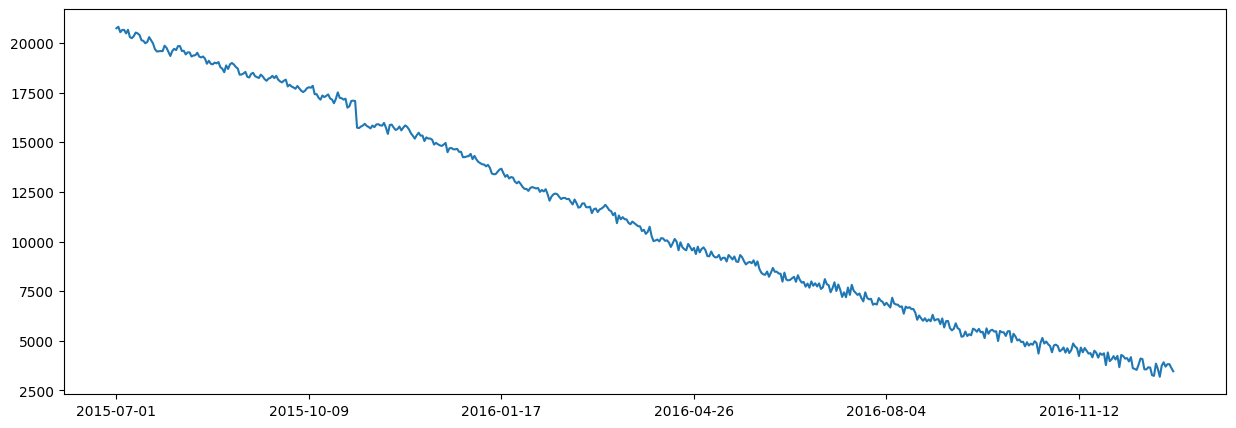

In [105]:
df_col=df.columns[1:]
df[df_col].isnull().sum().plot(figsize=(15,5))
plt.show()

##Insights:

Nulls/no entires have been decreasing overtime,indicating that there were no views for these dates.


Hence we can infer that the latest pages whihc have entires as nulls actually means there are no views for that page, hence imputation with 0 seems reasonable.

In [106]:
#imputation with value 0 seems to be a reasonable choice here.
df1=df1.fillna(0)

In [107]:
parts=df1['Page'].str.split('_')
parts

,Page
0,"[2NE1, zh.wikipedia.org, all-access, spider]"
1,"[2PM, zh.wikipedia.org, all-access, spider]"
2,"[3C, zh.wikipedia.org, all-access, spider]"
3,"[4minute, zh.wikipedia.org, all-access, spider]"
4,"[52, Hz, I, Love, You, zh.wikipedia.org, all-a..."
...,...
145058,"[Underworld, (serie, de, películas), es.wikipe..."
145059,"[Resident, Evil:, Capítulo, Final, es.wikipedi..."
145060,"[Enamorándome, de, Ramón, es.wikipedia.org, al..."
145061,"[Hasta, el, último, hombre, es.wikipedia.org, ..."


##Insights:



*   Teh Page section has pattern of having the language, accesstype, article and access origin.
*   All of these can be extracted depending on the use.



In [108]:
##Extraction (Feature Engineering):
df1['Language'] = df['Page'].str.extract(r'_([a-z]{2})\.wikipedia\.org_')
df1['Access_type']=parts.str[-2]
df1['article']=parts.str[:-3].str.join('_')
df1['access_origin']=parts.str[-1]

In [109]:
df1.head(5)

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31,Language,Access_type,article,access_origin
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,14.0,20.0,22.0,19.0,18.0,20.0,zh,all-access,2NE1,spider
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,9.0,30.0,52.0,45.0,26.0,20.0,zh,all-access,2PM,spider
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,4.0,4.0,6.0,3.0,4.0,17.0,zh,all-access,3C,spider
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,16.0,11.0,17.0,19.0,10.0,11.0,zh,all-access,4minute,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,11.0,27.0,13.0,36.0,10.0,zh,all-access,52_Hz_I_Love_You,spider


In [110]:
df1['Language'].unique()

array(['zh', 'fr', 'en', nan, 'ru', 'de', 'ja', 'es'], dtype=object)

In [111]:
df1['Language']=df1['Language'].fillna('Unknown')

In [112]:
df1['Language'].unique()

array(['zh', 'fr', 'en', 'Unknown', 'ru', 'de', 'ja', 'es'], dtype=object)

In [113]:
df1.isnull().sum()

,0
Page,0
2015-07-01,0
2015-07-02,0
2015-07-03,0
2015-07-04,0
...,...
2016-12-31,0
Language,0
Access_type,0
article,0


In [114]:
lang_name_mapping={'zh':'Chinese', 'fr':'French', 'en':'English',
                   'ru':'Russian', 'de':'German',
                   'ja':'Japanese', 'es':'Spanish'}
df1['Language'] = df1['Language'].map(lang_name_mapping)

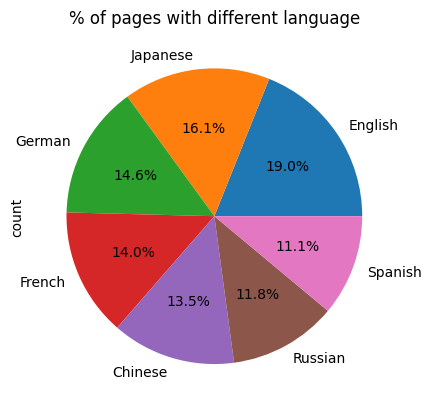

In [115]:
df1['Language'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different language')
plt.show()

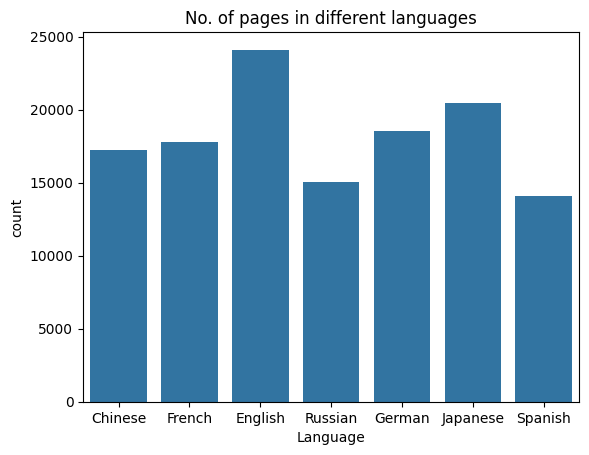

In [116]:
sns.countplot(x=df1['Language'],data=df1)
plt.title("No. of pages in different languages")
plt.show()

##Insights:


*   English Language Pages shows the highest count with a proportion of 19.1%.



In [117]:
print("% of pages in different languages")
round(df1['Language'].value_counts(normalize=True)*100,2)

% of pages in different languages


,proportion
Language,
English,18.95
Japanese,16.06
German,14.58
French,13.99
Chinese,13.54
Russian,11.81
Spanish,11.06


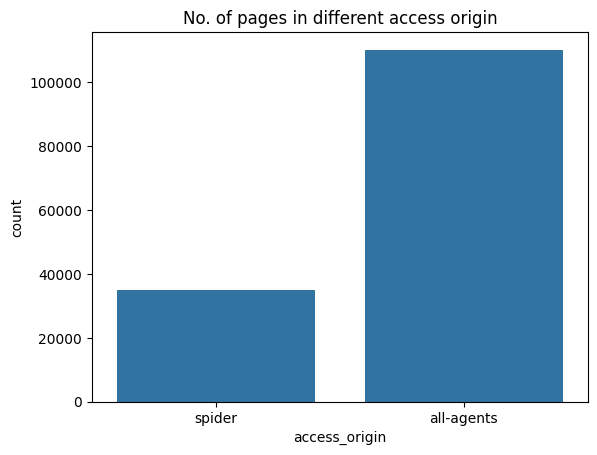

In [118]:
sns.countplot(x=df1['access_origin'],data=df1)
plt.title("No. of pages in different access origin")
plt.show()

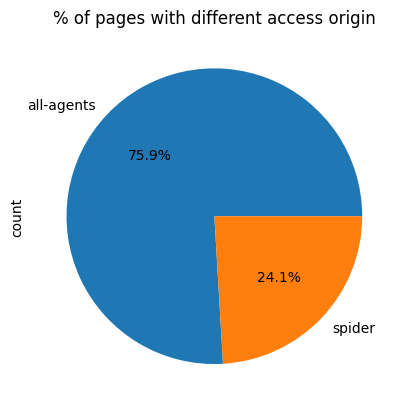

In [119]:
df1['access_origin'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different access origin')
plt.show()

##Insights:


*   All-agents acccess origin has a higher proportion as comapred to spider access origin.




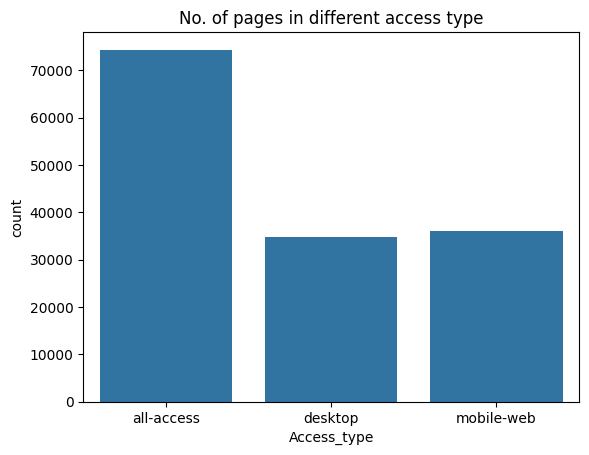

In [120]:
sns.countplot(x=df1['Access_type'],data=df1)
plt.title("No. of pages in different access type")
plt.show()

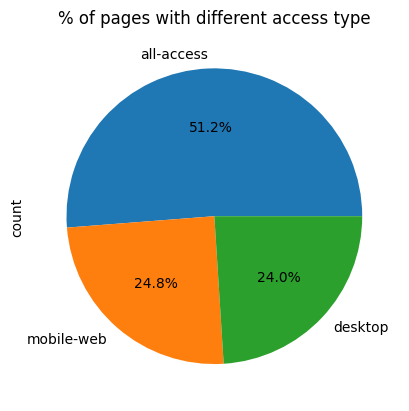

In [121]:
df1['Access_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='% of pages with different access type')
plt.show()

##Insights:


*   All-access has the highest proportion as compared to mobile-web and desktop access types.
*   While mobile-web and dekstop have almost similar proportions.



##Pivotting and Aggregation (Feature Engineering):

In [122]:
df1.columns

Index(['Page', '2015-07-01', '2015-07-02', '2015-07-03', '2015-07-04',
       '2015-07-05', '2015-07-06', '2015-07-07', '2015-07-08', '2015-07-09',
       ...
       '2016-12-26', '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30',
       '2016-12-31', 'Language', 'Access_type', 'article', 'access_origin'],
      dtype='object', length=555)

In [123]:
df3=df1.copy()
df_agg=df3.drop(columns=['Page', 'Access_type', 'article', 'access_origin']).groupby('Language').mean().T.reset_index()
df_agg['index'] = pd.to_datetime(df_agg['index'])
df_agg.set_index('index',inplace=True)
df_agg

Language,Chinese,English,French,German,Japanese,Russian,Spanish
index,,,,,,,
2015-07-01,240.582042,3513.862203,475.150994,714.968405,580.647056,629.999601,1085.972919
2015-07-02,240.941958,3502.511407,478.202000,705.229741,666.672801,640.902876,1037.814557
2015-07-03,239.344071,3325.357889,459.837659,676.877231,602.289805,594.026295,954.412680
2015-07-04,241.653491,3462.054256,491.508932,621.145145,756.509177,558.728132,896.050750
2015-07-05,257.779674,3575.520035,482.557746,722.076185,725.720914,595.029157,974.508210
...,...,...,...,...,...,...,...
2016-12-27,376.019618,6040.680728,858.413100,1085.095379,789.158680,1001.209426,1133.367901
2016-12-28,378.048639,5860.227559,774.155769,1032.640804,790.500465,931.987685,1178.290923
2016-12-29,350.719427,6245.127510,752.712954,994.657141,865.483236,897.282452,1112.171085


In [124]:
df_agg.index.duplicated().sum()

np.int64(0)

<Axes: xlabel='index', ylabel='No: of visits'>

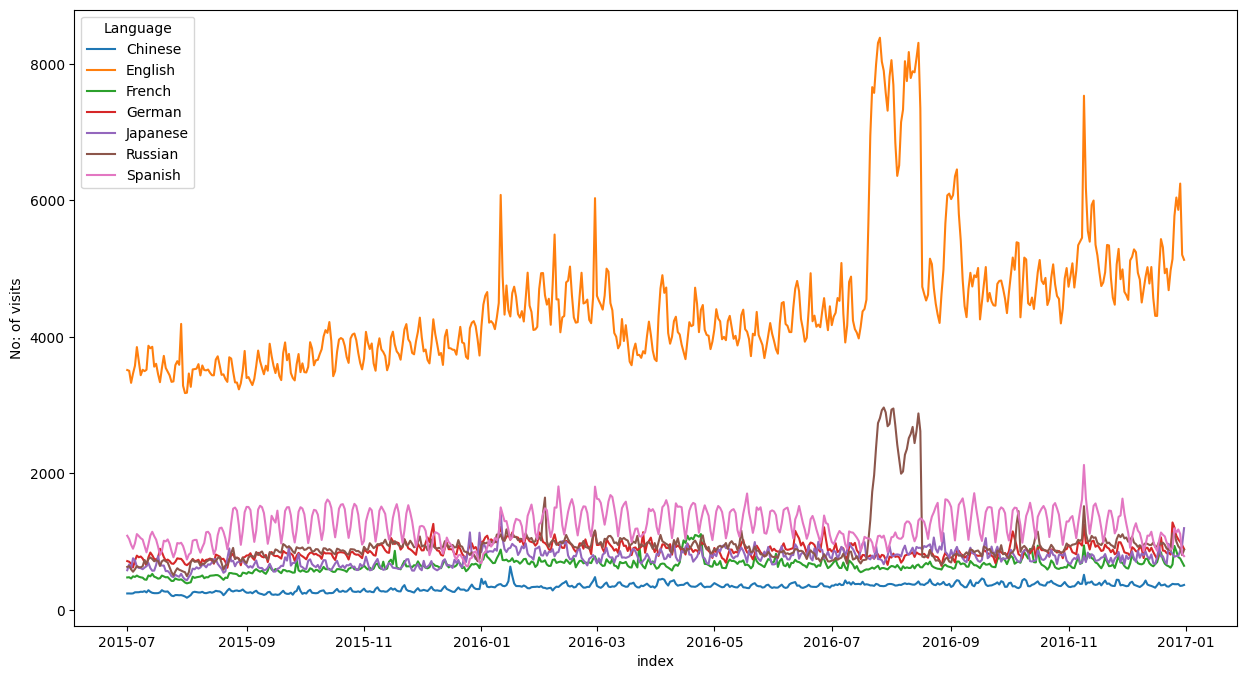

In [125]:
plt.figure(figsize=(15,8))
df_agg_reset = df_agg.reset_index()
df_melted = df_agg_reset.melt(id_vars='index', var_name='Language', value_name='No: of visits')
sns.lineplot(data=df_melted, x='index', y='No: of visits', hue='Language')

##Insights:


*   English Languages Pages Frequenecy is the highest with an upward trend w.r.t visits.
*   Unusual peaks between July to August.


*   Spanish Language shows high volatility with mulitple small consistent peaks.
*   The Chinese Language Page trend seems to be more stable.





##Stationarity, Detrending, ACF and PACF

In [126]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

In [127]:
##dickyfuller test:

def dickyfuller_test(x):
  print(x.name,':')
  p_value=sm.tsa.stattools.adfuller(x)[1]
  if (p_value < 0.05):
        print('The time series is stationary')
  else:
      print('The time series is not stationary')

In [128]:
col=df_agg.columns
df_agg[col].apply(dickyfuller_test)

Chinese :
The time series is not stationary
English :
The time series is not stationary
French :
The time series is not stationary
German :
The time series is not stationary
Japanese :
The time series is not stationary
Russian :
The time series is stationary
Spanish :
The time series is stationary


,0
Language,
Chinese,None
English,None
French,None
German,None
Japanese,None
Russian,None
Spanish,None


##Insights:
Dicky fuller test has been performed.  Russian and Spanish Languages are stationary, while the rest are not stationary.

In [129]:
ts_eng=df_agg['English']

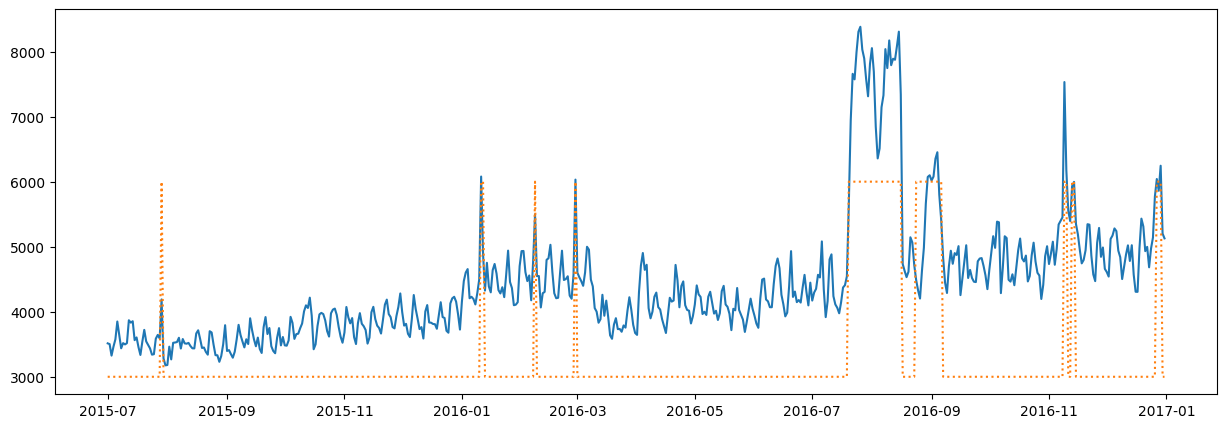

In [130]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ts_eng.index, ts_eng)
ax.plot(ts_eng.index, (exog+1)*3000, ':')
plt.show()

##Insights:


*   The Above plots confirms we have and Additive Time Series with linear trend and Seasonality.

*   The plot also confirms unusual peaks can be due to special events.






##Decomposition and Differencing (Using Seasonal Decompose):

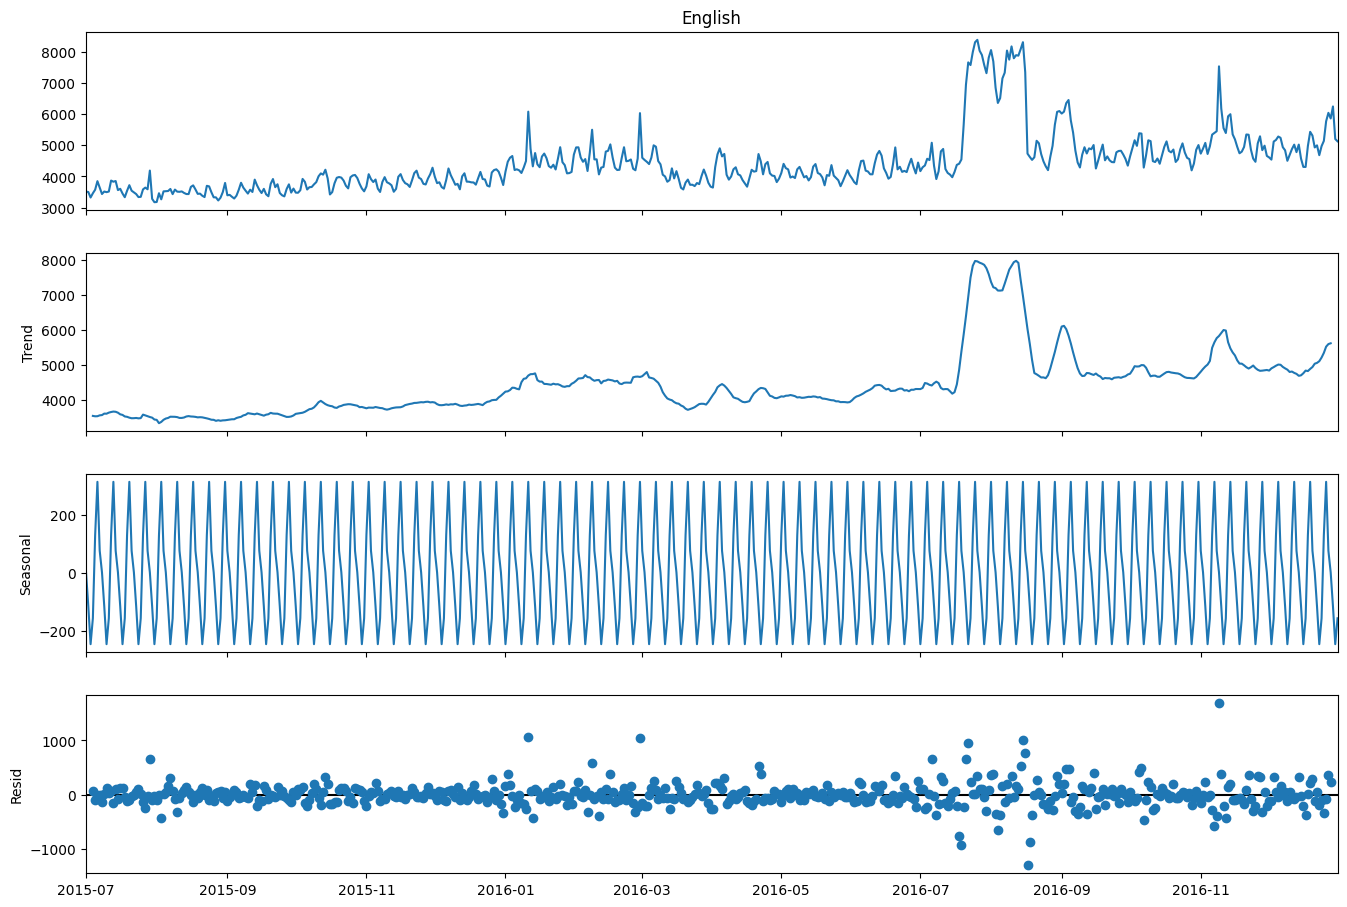

In [131]:
import statsmodels.api as sm

model = sm.tsa.seasonal_decompose(ts_eng, model='additive')
fig = model.plot()
fig.set_size_inches(15, 10)
plt.show()

##Insights:


*   The ACF plot shows the correlation of a time series with itself at different lags, while the PACF plot shows the correlation of a time series with itself at different lags, after removing the effects of the previous lags

*   The ACF plot can be used to identify the order of an AR model. The order of an AR model is the number of lags that are included in the model. The ACF plot will show spikes at the lags that are included in the model.
*   The PACF plot can be used to identify the order of an MA model. The order of an MA model is the number of lags that are included in the model. The PACF plot will show spikes at the lags that are included in the model





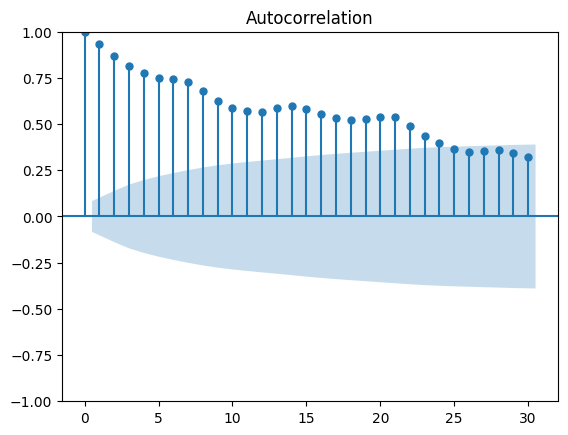

In [132]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_eng, lags=30)
plt.show()

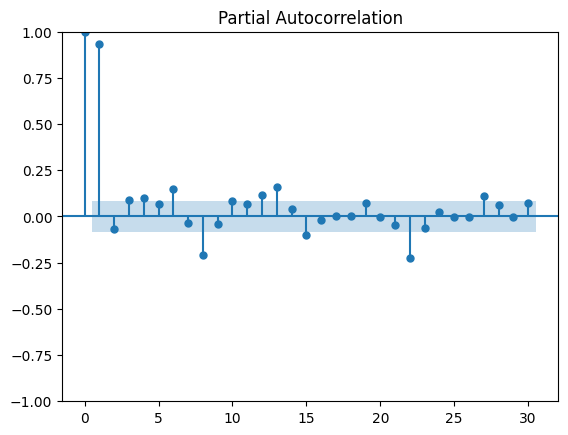

In [133]:
plot_pacf(ts_eng, lags=30)
plt.show()

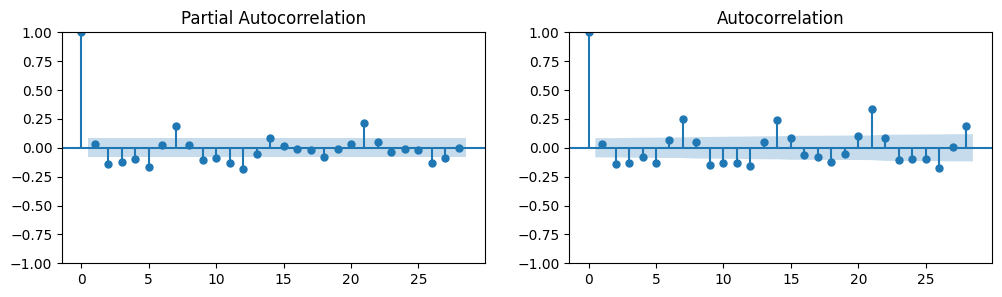

In [134]:
fig, axs = plt.subplots(1,2, figsize=(12, 3))
plot_pacf(ax=axs[0], x=ts_eng.diff(1).dropna())
plot_acf(ax=axs[1], x=ts_eng.diff(1).dropna())
plt.show()

###Insights:
Since neither ACF nor PACF show significant spikes at lag 1 after differencing, the series exhibits weak short-term autocorrelation, so small values of p and q are sufficient.

##Model Building and Evaluation:

In [135]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as  mape_func)

def performance(actual, predicted, print_metrics=True):
    MAE = round(mae(actual, predicted), 3)
    RMSE = round(mse(actual, predicted)**0.5, 3)
    MAPE = round( mape_func(actual, predicted), 3)
    if(print_metrics==True):
        print('MAE :', MAE)
        print('RMSE :', RMSE)
        print('MAPE:', MAPE)
    return MAE, RMSE, MAPE

In [136]:
ts_eng.shape

(550,)

In [137]:
train=ts_eng[:521]
test=ts_eng[521:]

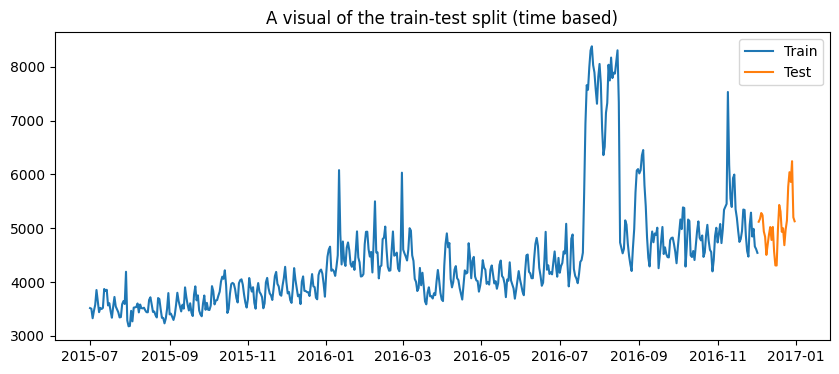

In [138]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.title("A visual of the train-test split (time based)")
plt.legend()
plt.show()


###ARIMA Model:

In [139]:
##ARIMA Model:

from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(train, order=(0,1,0))
result = model.fit()
forecast = result.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [140]:
mape = np.mean(np.abs((test - forecast) / test)) * 100
mape

np.float64(10.761154450089231)

In [141]:
model = ARIMA(train, order=(1,1,0))
result = model.fit()
forecast = result.forecast(steps=len(test))
mape = np.mean(np.abs((test - forecast) / test)) * 100
mape

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


np.float64(10.799093689870562)

In [142]:
model = ARIMA(train, order=(0,1,1))
result = model.fit()
forecast = result.forecast(steps=len(test))
mape = np.mean(np.abs((test - forecast) / test)) * 100
mape

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


np.float64(10.811296383377673)

In [143]:
model = ARIMA(train, order=(1,1,1))
result = model.fit()
forecast = result.forecast(steps=len(test))
#forecast.index=test.index
mape_arima_value = np.mean(np.abs((test - forecast) / test)) * 100
mape_arima_value

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


np.float64(7.139425658295682)

###Insights:
ARIMA at (1,1,1) shows the best MAPE. Giving non-seasonal ARIMA performs the best. Recommended to use SARIMA or SARIMAX.

Note: (We have differnt values for p,q,d to see which order gives the best MAPE).

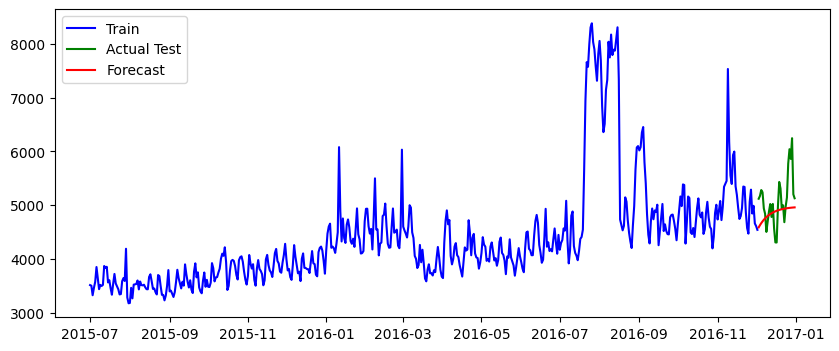

In [144]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train', color='blue')
plt.plot(test, label='Actual Test', color='green')
plt.plot(forecast, label='Forecast', color='red')

plt.legend()
plt.show()

##Insights:
Even though ARIMA model was implemented, it doesnt perform well as it doesnt take into consideration the season orders and the exogenous variable (which might be the reason for the unusal spikes).

##SARIMAX Model:

In [145]:
exog.shape

(550, 1)

In [146]:
exog_train=exog[:521]
exog_test=exog[521:]

In [147]:
!pip install pmdarima

In [148]:
from pmdarima import auto_arima
model = auto_arima(train,seasonal=True,m=7,stepwise=True,suppress_warnings=True)

print("Best ARIMA order:", model.order)
print("Best seasonal order:", model.seasonal_order)

Best ARIMA order: (1, 1, 1)
Best seasonal order: (2, 0, 0, 7)


###Insights:
We got the best arima order and seasonal orders using the PMDARIMA. The orders are given above.

In [149]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Align indices of exogenous variables with the time series data
exog_train.index = train.index
exog_test.index = test.index

model = SARIMAX(train,exog=exog_train, order=(1,1,1),seasonal_order=(2,0,1,7),enforce_stationarity=False,enforce_invertibility=False)
result = model.fit()
forecast = result.forecast(steps=len(test),exog=exog_test)
forecast.index = test.index
mape1 = np.mean(np.abs((test - forecast) / test)) * 100
mape1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


np.float64(4.5486698565117845)

In [150]:
performance(test, forecast.values, print_metrics=True)

MAE : 224.17
RMSE : 272.972
MAPE: 0.045


(224.17, 272.972, 0.045)

##Insights:
We obtianed a MAPE of 4.54 which is performing much better than the ARIMA Model used above. Also PMDARIMA was used to get the best order, seasonal orders respectively. The exogenous variable was introduced as well.

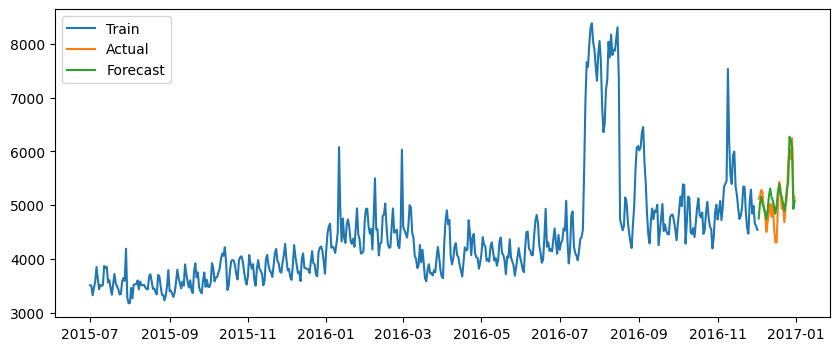

In [151]:
plt.figure(figsize=(10,4))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.show()

##Facebook Prophet

In [152]:
#!pip install prophet

In [153]:
df_prophet = ts_eng.reset_index()
df_prophet.columns = ['ds', 'y']

df_prophet['campaign'] = exog['Exog'].values
df_prophet

,ds,y,campaign
0,2015-07-01,3513.862203,0
1,2015-07-02,3502.511407,0
2,2015-07-03,3325.357889,0
3,2015-07-04,3462.054256,0
4,2015-07-05,3575.520035,0
...,...,...,...
545,2016-12-27,6040.680728,1
546,2016-12-28,5860.227559,1
547,2016-12-29,6245.127510,1
548,2016-12-30,5201.783018,0


In [154]:
df_prophet = df_prophet[['ds', 'y']].copy()
df_prophet['campaign'] = exog['Exog'].values

In [155]:
df_prophet.columns

Index(['ds', 'y', 'campaign'], dtype='object')

In [156]:
train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

In [157]:
from prophet import Prophet
import pandas as pd

df_prophet = ts_eng.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['campaign'] = exog['Exog'].values

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)
model.add_regressor('campaign')
model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)
future = pd.merge(future, df_prophet[['ds', 'campaign']], on='ds', how='left')
future['campaign'] = future['campaign'].fillna(0) ##safety measure.

forecast = model.predict(future)

In [158]:
df_prophet.shape

(550, 3)

In [159]:
future.shape

(550, 2)

In [160]:
forecast_test = forecast.tail(30)
forecast_test.head(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,campaign,...,extra_regressors_additive,extra_regressors_additive_lower,extra_regressors_additive_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
520,2016-12-02,5009.614916,4149.882030,5439.426686,5009.614916,5009.614916,-211.353932,-211.353932,-211.353932,0.0,...,0.0,0.0,0.0,-211.353932,-211.353932,-211.353932,0.0,0.0,0.0,4798.260983
521,2016-12-03,5013.703312,4257.170922,5520.086883,5004.060162,5034.951670,-130.244393,-130.244393,-130.244393,0.0,...,0.0,0.0,0.0,-130.244393,-130.244393,-130.244393,0.0,0.0,0.0,4883.458919
522,2016-12-04,5017.791708,4493.051749,5765.853901,4983.355536,5063.694808,140.178320,140.178320,140.178320,0.0,...,0.0,0.0,0.0,140.178320,140.178320,140.178320,0.0,0.0,0.0,5157.970029
523,2016-12-05,5021.880105,4645.364162,5906.265872,4940.154519,5109.517319,263.096897,263.096897,263.096897,0.0,...,0.0,0.0,0.0,263.096897,263.096897,263.096897,0.0,0.0,0.0,5284.977002
524,2016-12-06,5025.968501,4457.870332,5719.977133,4907.805713,5161.169635,67.517701,67.517701,67.517701,0.0,...,0.0,0.0,0.0,67.517701,67.517701,67.517701,0.0,0.0,0.0,5093.486203


In [161]:
mape_prophet = (np.mean(np.abs((test_prophet['y'] - forecast_test['yhat']) / test_prophet['y']))* 100)
mape_prophet


np.float64(4.554127715494085)

In [162]:
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

MAE : 225.573
RMSE : 283.915
MAPE: 0.046


(225.573, 283.915, 0.046)

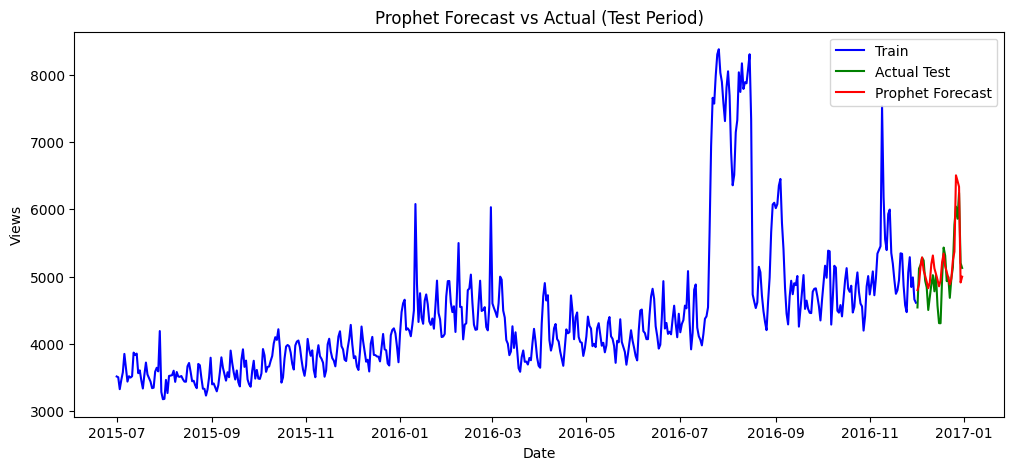

In [163]:
plt.figure(figsize=(12,5))
plt.plot(train_prophet['ds'],train_prophet['y'],label='Train',color='blue')
plt.plot(test_prophet['ds'],test_prophet['y'],label='Actual Test',color='green')
plt.plot(forecast_test['ds'],forecast_test['yhat'],label='Prophet Forecast',color='red')
plt.legend()
plt.title('Prophet Forecast vs Actual (Test Period)')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

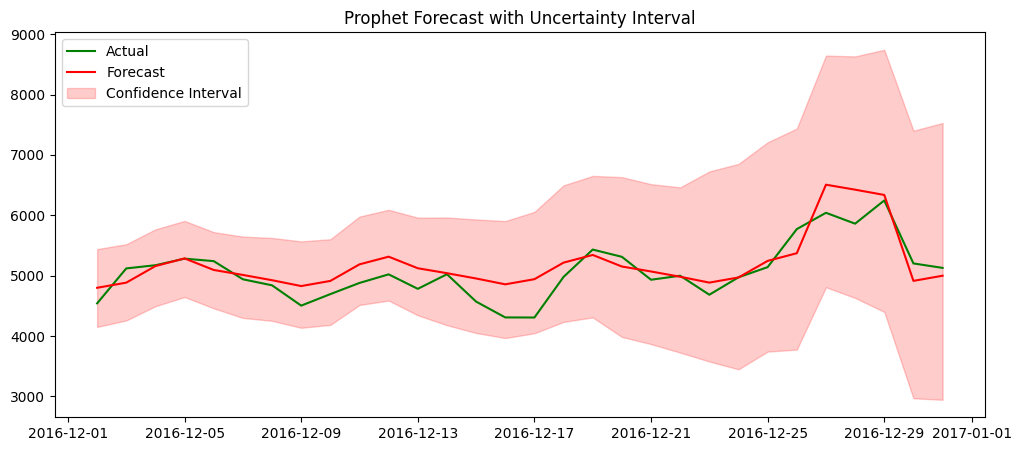

In [164]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()


##Insights:
A Mape of 4.5% shows that prophet is doing an amazing job in forecasting as compared to SARIMAX too. Even though both gave an exempleric results, the need for an exogenous variable (if available) is very important in forecasting.

MAE : 17.967
RMSE : 21.032
MAPE: 0.05


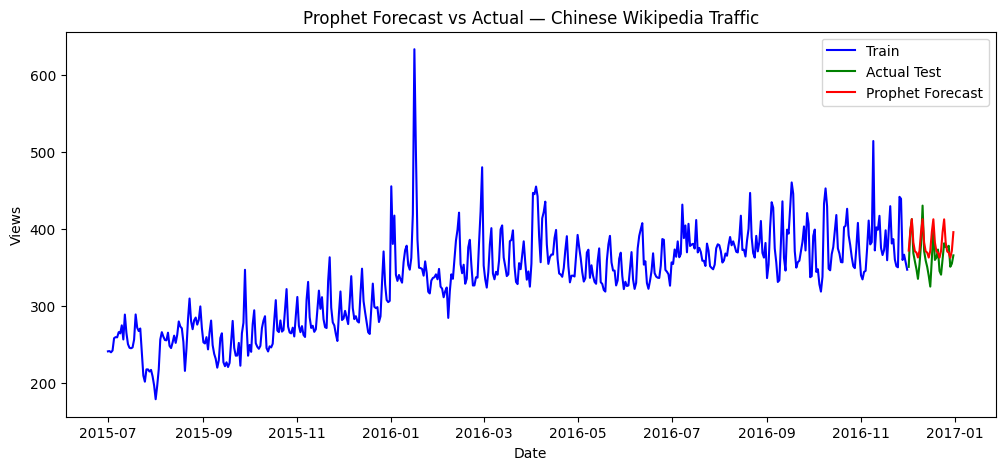

In [165]:
##Chinese Data:

ts=df_agg['Chinese']
df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)

model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)
forecast_test = forecast.tail(30)
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

plt.figure(figsize=(12,5))

plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

plt.legend()
plt.title('Prophet Forecast vs Actual — Chinese Wikipedia Traffic')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

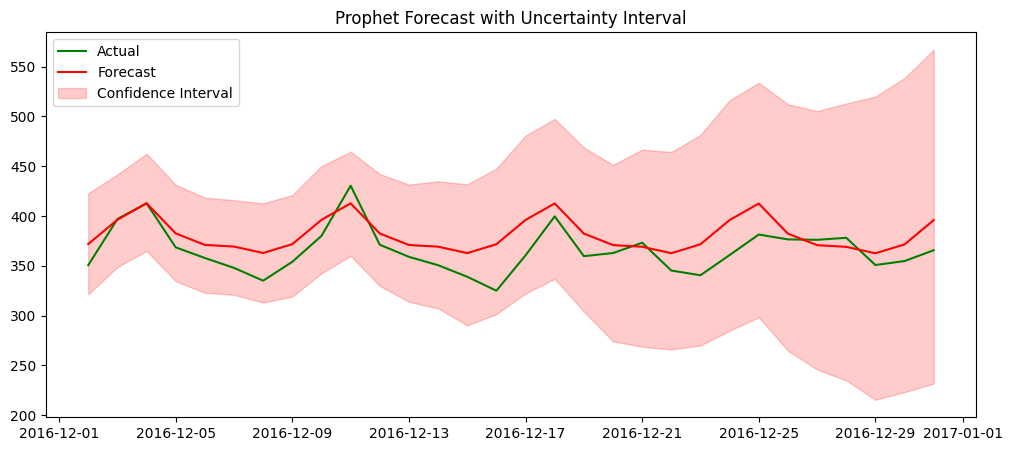

In [166]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()


MAE : 50.646
RMSE : 66.146
MAPE: 0.07


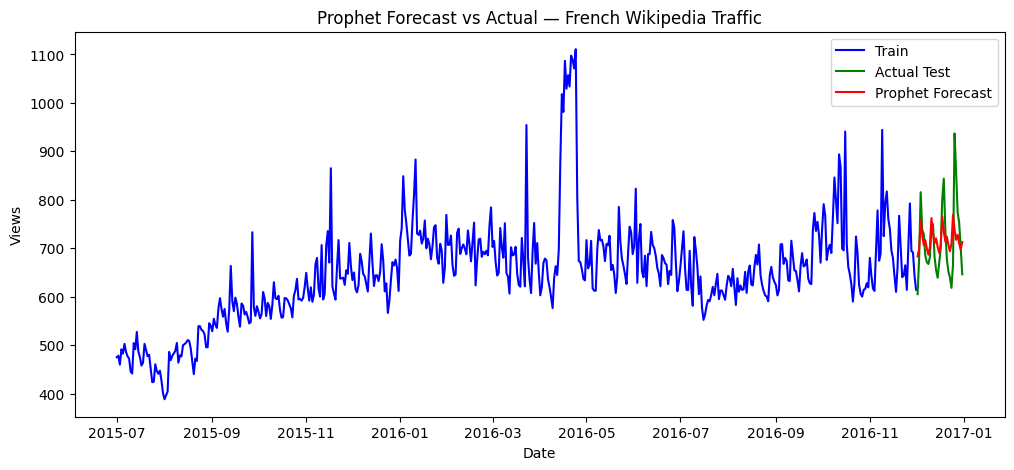

In [167]:
##French:

ts=df_agg['French']
df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)

model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)
forecast_test = forecast.tail(30)
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

plt.figure(figsize=(12,5))

plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

plt.legend()
plt.title('Prophet Forecast vs Actual — French Wikipedia Traffic')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

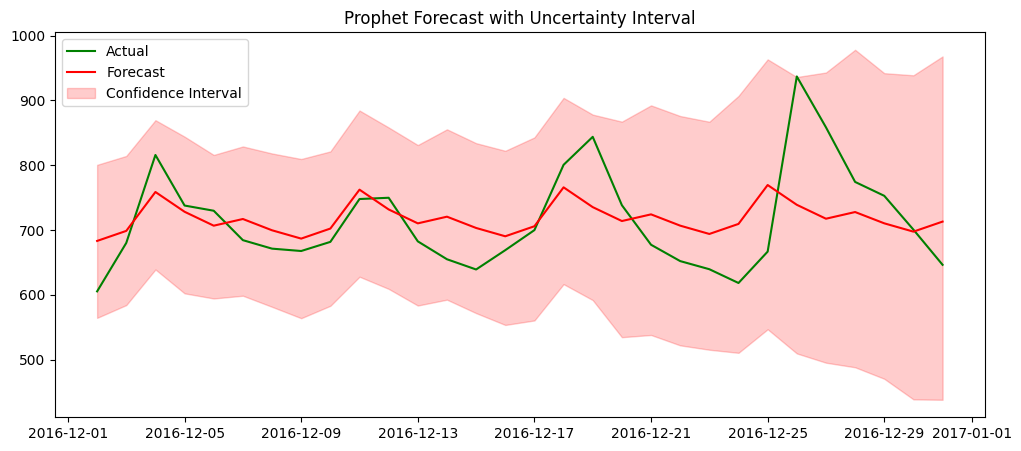

In [168]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()

MAE : 91.179
RMSE : 105.252
MAPE: 0.101


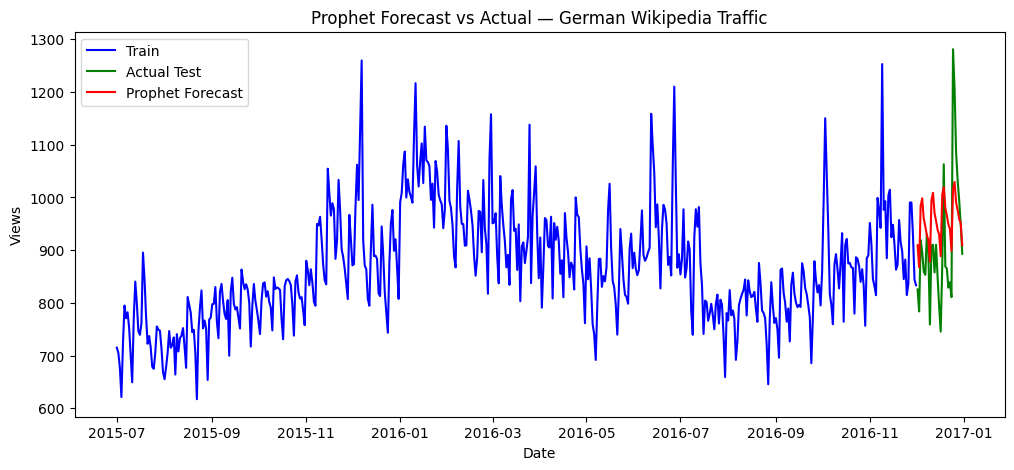

In [169]:
##German:

ts=df_agg['German']
df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=0.3)

model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)
forecast_test = forecast.tail(30)
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

plt.figure(figsize=(12,5))

plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

plt.legend()
plt.title('Prophet Forecast vs Actual — German Wikipedia Traffic')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

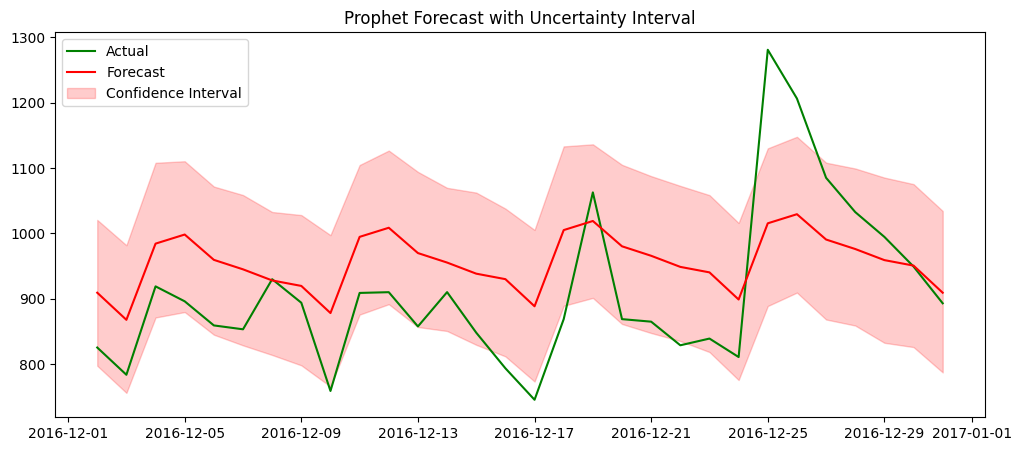

In [170]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()

MAE : 113.177
RMSE : 152.593
MAPE: 0.129


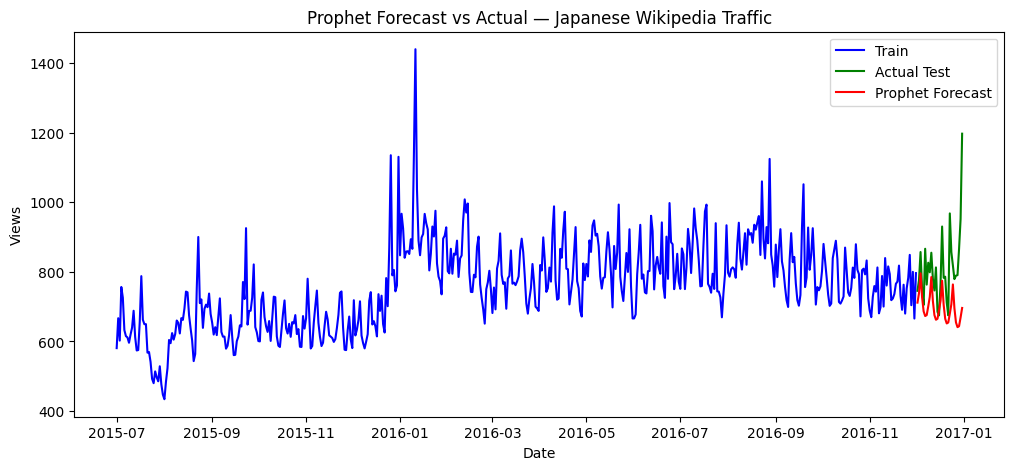

In [171]:
##Japanese:
ts3=df_agg['Japanese']
df_prophet = ts3.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)

model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)
forecast_test = forecast.tail(30)
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

plt.figure(figsize=(12,5))

plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

plt.legend()
plt.title('Prophet Forecast vs Actual — Japanese Wikipedia Traffic')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

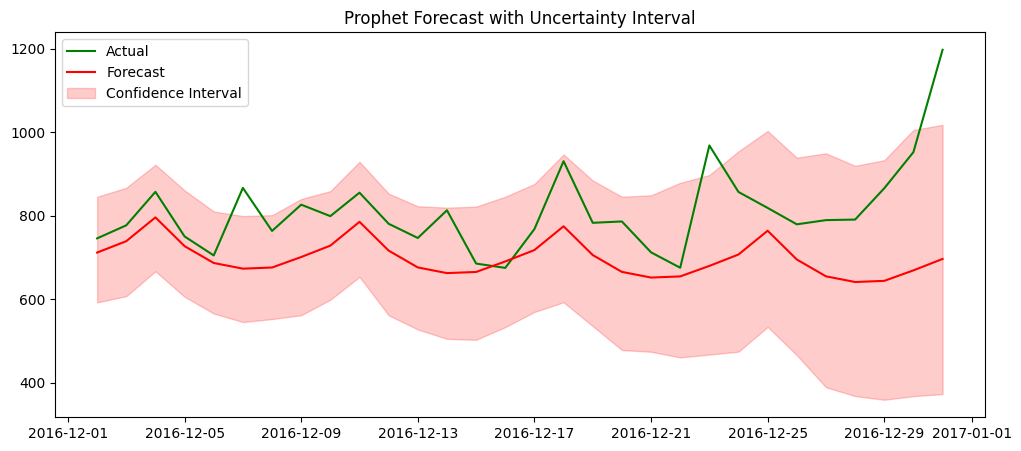

In [172]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()

MAE : 68.745
RMSE : 76.852
MAPE: 0.074


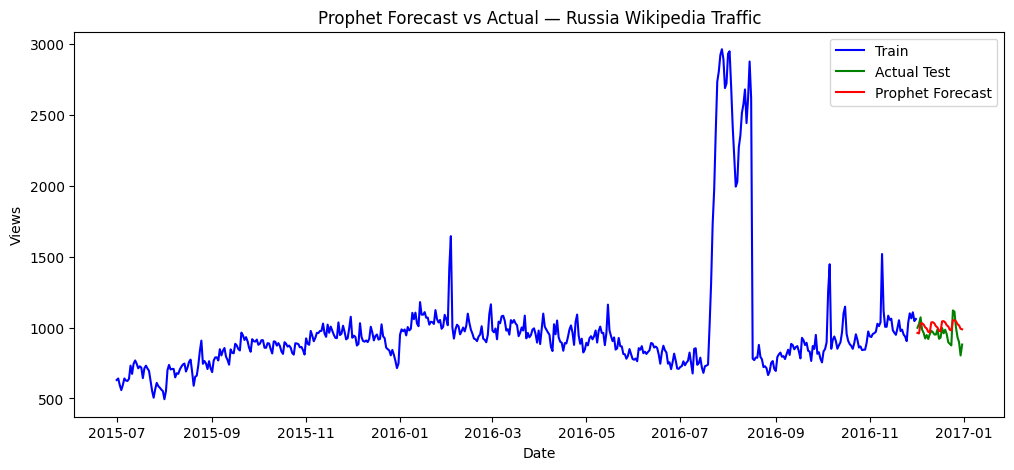

In [173]:
##Russian:
ts=df_agg['Russian']
df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)

model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)
forecast_test = forecast.tail(30)
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

plt.figure(figsize=(12,5))

plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

plt.legend()
plt.title('Prophet Forecast vs Actual — Russia Wikipedia Traffic')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

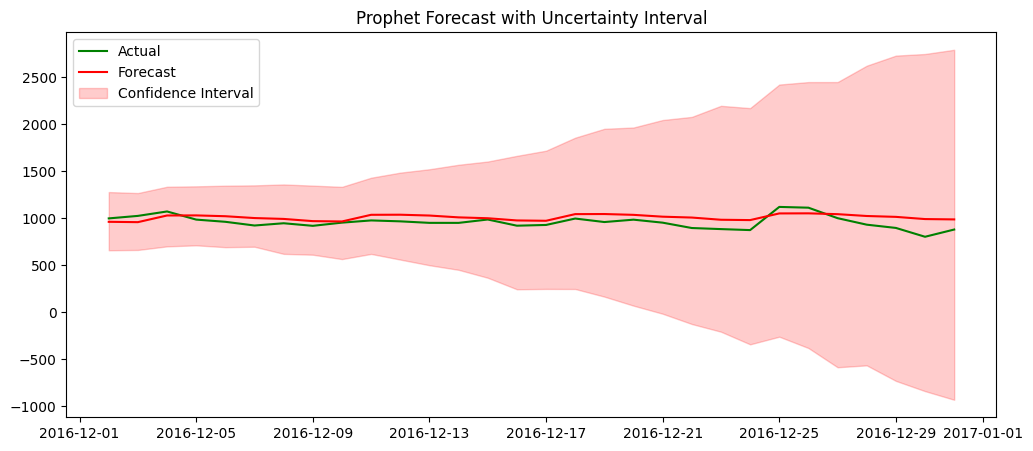

In [174]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()

MAE : 293.836
RMSE : 304.035
MAPE: 0.288


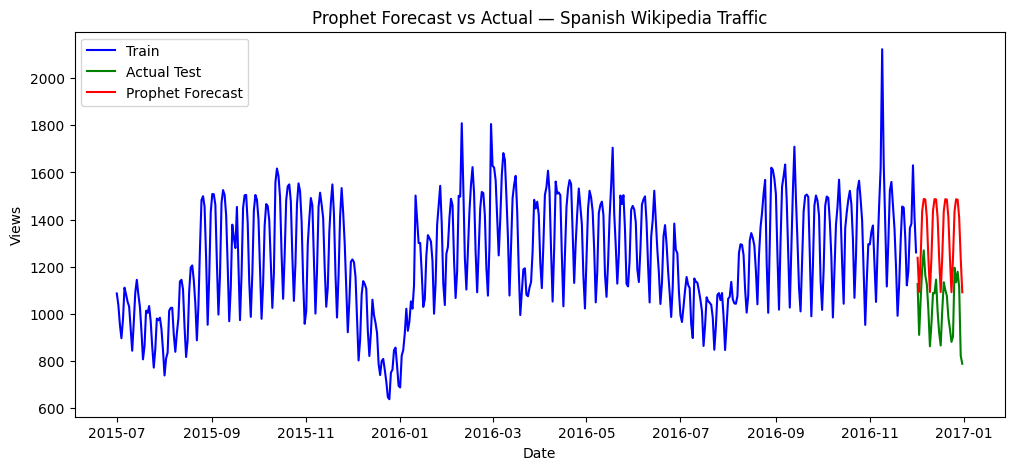

In [175]:
##Spanish:
ts=df_agg['Spanish']
df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']

train_prophet = df_prophet.iloc[:-30]
test_prophet  = df_prophet.iloc[-30:]

model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)

model.fit(train_prophet)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)
forecast_test = forecast.tail(30)
performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

plt.figure(figsize=(12,5))

plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

plt.legend()
plt.title('Prophet Forecast vs Actual — Spanish Wikipedia Traffic')
plt.xlabel('Date')
plt.ylabel('Views')
plt.show()

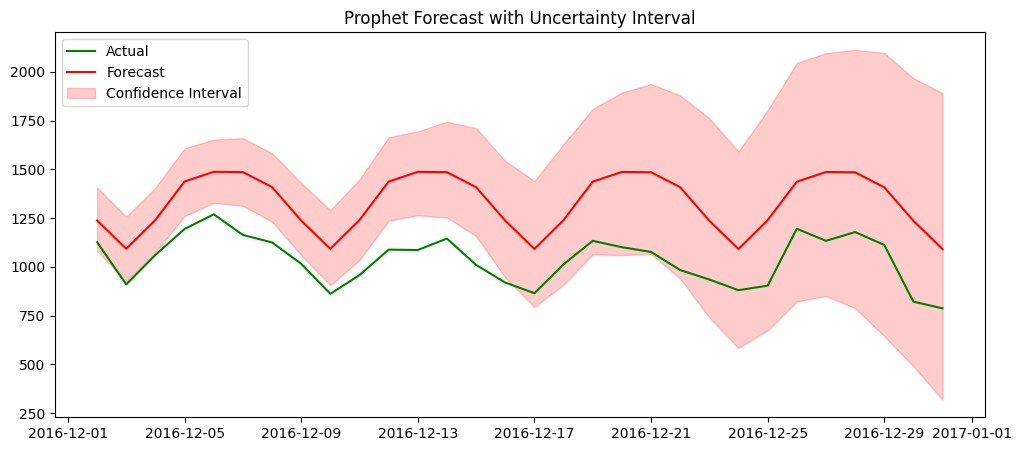

In [176]:
plt.figure(figsize=(12,5))

plt.plot(test_prophet['ds'], test_prophet['y'], label='Actual', color='green')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.fill_between(forecast_test['ds'],forecast_test['yhat_lower'],forecast_test['yhat_upper'],color='red',alpha=0.2,label='Confidence Interval')

plt.legend()
plt.title('Prophet Forecast with Uncertainty Interval')
plt.show()

##Pipeline for different languages:

In [177]:
##Pipeline:

def Pipe(x):
  for i in x:

    ts=df_agg[i]
    df_prophet = ts.reset_index()
    df_prophet.columns = ['ds', 'y']

    train_prophet = df_prophet.iloc[:-30]
    test_prophet  = df_prophet.iloc[-30:]

    model = Prophet(interval_width=0.95,daily_seasonality=False,yearly_seasonality=False,weekly_seasonality=True,changepoint_prior_scale=4)

    model.fit(train_prophet)

    future = model.make_future_dataframe(periods=30)

    forecast = model.predict(future)
    forecast_test = forecast.tail(30)
    performance(test_prophet['y'], forecast_test['yhat'], print_metrics=True)

    plt.figure(figsize=(12,5))

    plt.plot(train_prophet['ds'], train_prophet['y'],label='Train', color='blue')
    plt.plot(test_prophet['ds'], test_prophet['y'],label='Actual Test', color='green')
    plt.plot(forecast_test['ds'], forecast_test['yhat'],label='Prophet Forecast', color='red')

    plt.legend()
    plt.title(f'Prophet Forecast vs Actual — {i} Wikipedia Traffic')
    plt.xlabel('Date')
    plt.ylabel('Views')
    plt.show()


In [178]:
df_agg.columns

Index(['Chinese', 'English', 'French', 'German', 'Japanese', 'Russian',
       'Spanish'],
      dtype='object', name='Language')

MAE : 17.967
RMSE : 21.032
MAPE: 0.05


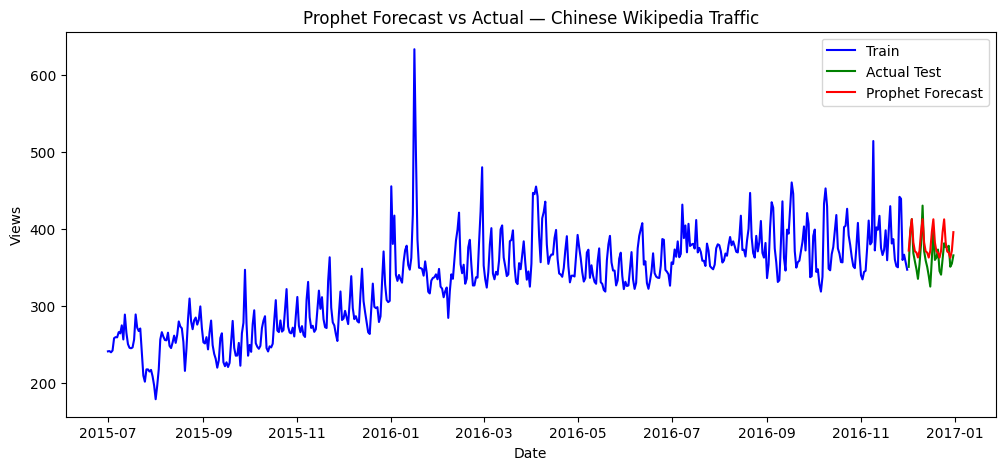

MAE : 50.646
RMSE : 66.146
MAPE: 0.07


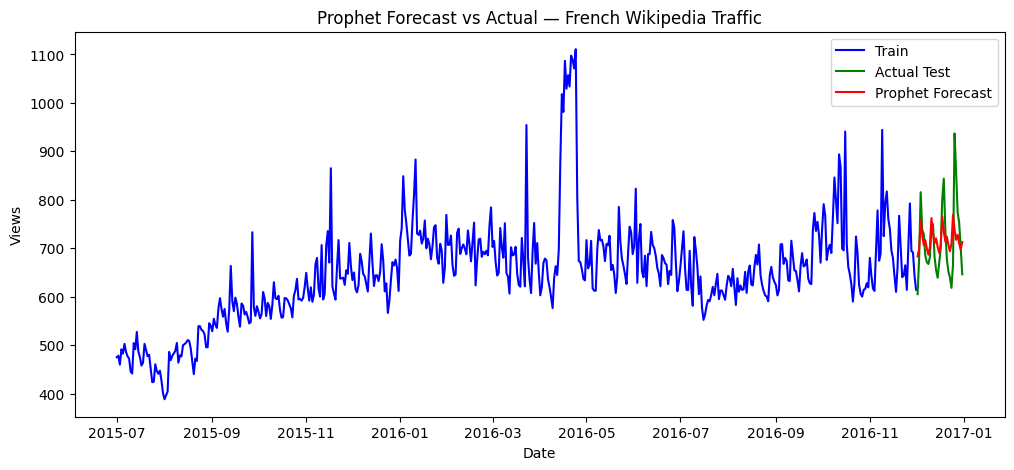

MAE : 90.682
RMSE : 104.878
MAPE: 0.1


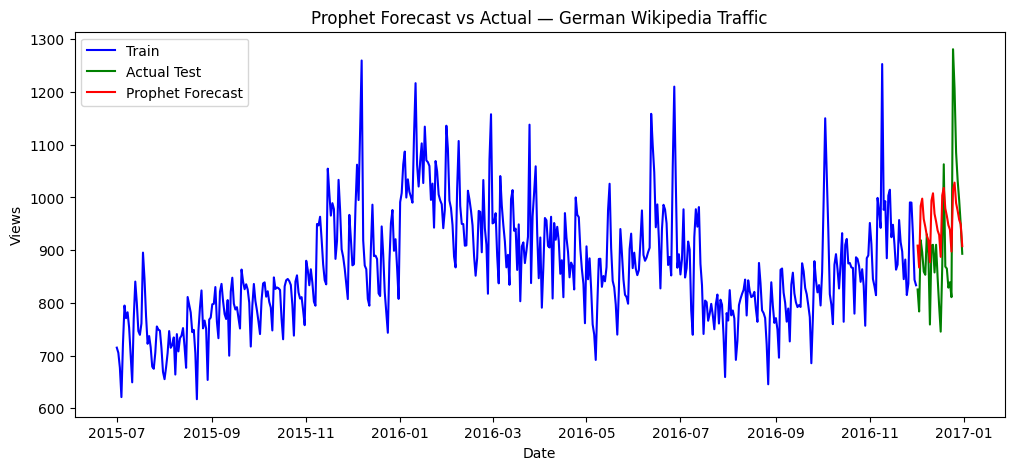

MAE : 113.177
RMSE : 152.593
MAPE: 0.129


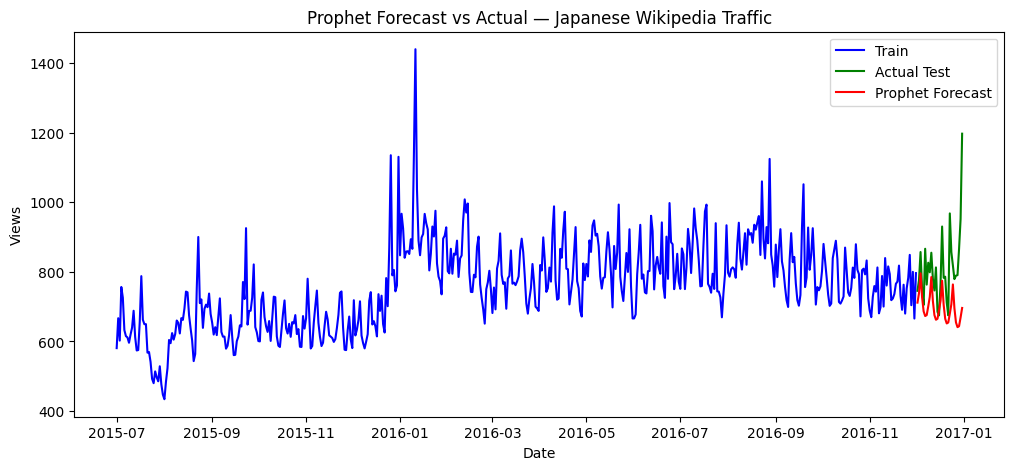

MAE : 68.745
RMSE : 76.852
MAPE: 0.074


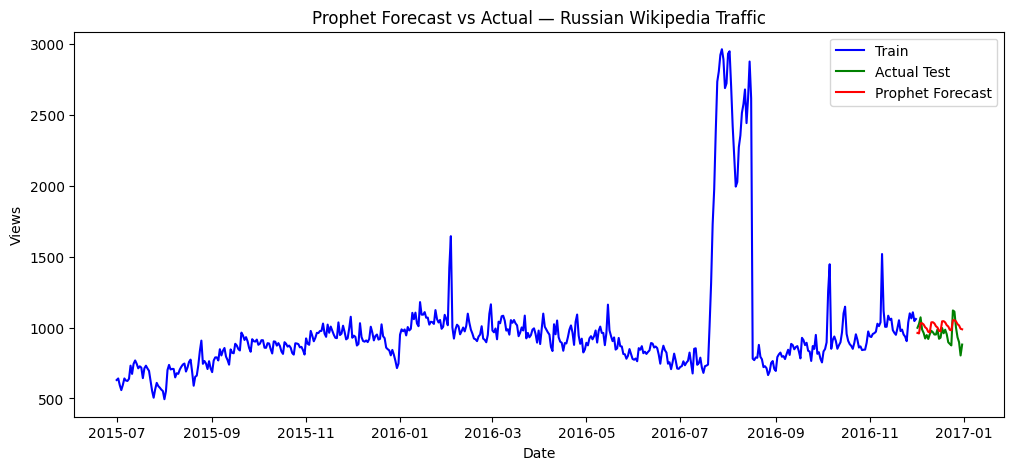

MAE : 293.836
RMSE : 304.035
MAPE: 0.288


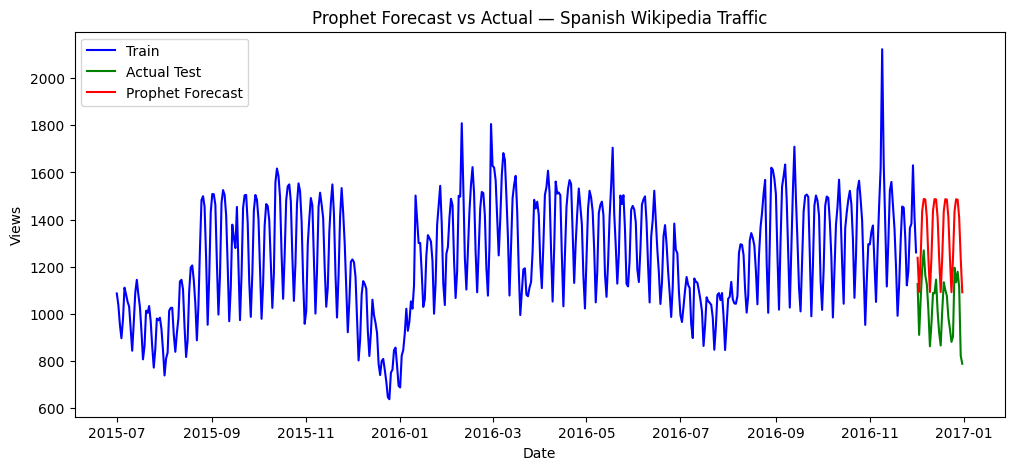

In [179]:
lis=['Chinese', 'French', 'German', 'Japanese', 'Russian',
       'Spanish']
Pipe(lis)

##Insights:


*   Facebook Prophet is doing a wonderful job in the forecasting. While SARIMAX is also performing well, hence it show  the need for a seasonal order as well as an exogenous vairable (if available) for reliable-forecating with iintervals.
*   A single Pipeline has also been created to forecast on other Languages.
('Chinese', 'French', 'German', 'Japanese', 'Russian',
       'Spanish').
*   Chinese has a MAPE of 5%.

*   French has a MAPE of 7%.
*   German has a MAPE of 10%.

*   Japanese has a MAPE of 12%.
*   Russian has a MAPE of 7%.




*   Spanish has a MAPE of 28%.




Note: The above Lanagues (except English) did not have any exogenous variables associated with it, hence the highes MAPE can be related to the exogenous variable being absent.





#Result Interpretation:

*   There are 7 known language pages in the dataset - English, Japanese, German, French, Chinese, Russian and Spanish. With English being the most visitied accounting to 19.1%.

*   Decomposition helps in understanding the underlying trend, seasonality and error(residual) in the time series data.

*   Dickey-Fuller test was done to check for Stationarity  with different Languages.
*   Since Exogenous variable was available for English Pages, modelling on SARIMAX and Facebook Prophet can be used for forecasting, while leaning more on Facebook Prophet as a good model.


*   Without the exogenous variable, it becomes impossible to make accurate predictions. This is demonstarted by the plots of other languages which do not have exogneous variables. (plots from the pipeline).


*   ARIMA fails as a good model as it used for non-seasonal time series data with trend and autocorrelations.

